# 4) Run GPEs #

Code for running the ECO-FAST and ORG-FAST analysis using gaussian process regression. <br>
<br>
Inputs: <br>
Metrics_PFT.nc - created by notebook 3 and contains metrics for GPP, Stress, and Drought Sensitivity for the primary PFT of each grid cell (y vars in the ORG-FAST analysis) <br>
Metrics_GC.nc - created by notebook 3 and contains metrics for Drought Sensitivity for entire grid cell (y vars in the ECO-FAST analysis)<br>
Traits.nc - created by notebook 2 and contains the parameter values, both for individual PFTs and gridcell weighted means and coefficient of variations (y vars in both analyses)<br>
primaryPFT.nc - a helper dataset for selecting the most abundant pft (based on cveg) in each grid cell <br>
<br>
Ouputs:<br>
Metrics.nc - contains select output variables used for analysis

## Load packages ##

In [1]:
import importlib.util
import os
import pickle
import warnings
from math import pi
import cartopy.crs as ccrs
import matplotlib
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import xarray as xr
from matplotlib.colors import LinearSegmentedColormap
from pypalettes import load_cmap
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from tqdm import tqdm
import gpflow
from esem import gp_model
from esem.sampler import MCMCSampler
from esem.utils import get_random_params, leave_one_out, prediction_within_ci
from SALib.analyze import fast
from SALib.sample import fast_sampler
from scipy import stats
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import tensorflow as tf

repo_dir = os.getcwd()
repo_dir = os.path.dirname(repo_dir)

2025-09-15 13:12:22.144348: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-09-15 13:12:22.421769: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-09-15 13:12:22.421849: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-09-15 13:12:22.442273: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-09-15 13:12:22.488895: I tensorflow/core/platform/cpu_feature_guar

## Functions ##

In [53]:
def rf(data, xvar, yvar, ntrees = None):
    scaler_x = StandardScaler()
    scaler_y = StandardScaler()
    
    if 'year' in data.dims:
        data = data.median(dim='year', skipna=True)[xvar + [yvar]]
    else:
        data = data[xvar + [yvar]]
    mean_y = data[yvar].mean(skipna=True).values.item()
    std_y = data[yvar].std(skipna=True).values.item()
    data[yvar] = data[yvar].where(np.abs(data[yvar] - mean_y) <= 3 * std_y)
    
    data = data.to_dataframe()
    data.reset_index(inplace=True)
    data = data.replace([np.inf, -np.inf], np.nan).dropna()
    ens_column = data['ens']
    gridcell_column = data['gridcell'] # Save gridcell column if needed
    #data = data.drop(['gridcell', 'ens'], axis=1)
    
    # Fit the scaler only on the X variables (independent variables)
    data_x = pd.DataFrame(scaler_x.fit_transform(data[xvar]), columns=xvar) 
    if yvar == 'Stress':
        data_y = pd.DataFrame(data[[yvar]], columns=[yvar])
    else:
        data_y = pd.DataFrame(
            scaler_y.fit_transform(data[[yvar]]),
            columns=[yvar]
        )
    
    # Concatenate scaled X with original y
    #data = pd.concat([data_x, data_y, ens_column], axis=1)
    data = pd.concat([data[xvar], data[[yvar]], ens_column], axis=1)
    data = data.dropna()
    
    numbers = range(1, 501)
    train_numbers, test_numbers = train_test_split(numbers, test_size=0.3, random_state=39)
    
    df_train = data[data.ens.isin(train_numbers)]
    df_test = data[data.ens.isin(test_numbers)]
    
    df_train = df_train.dropna()
    df_train = df_train.replace([np.inf, -np.inf], np.nan).dropna()
    X_train = df_train[xvar]
    y_train = df_train[yvar]
    
    df_test = df_test.dropna()
    df_test = df_test.replace([np.inf, -np.inf], np.nan).dropna()
    X_test = df_test[xvar]
    y_test = df_test[yvar]
    
    rf_model = RandomForestRegressor(n_estimators=10, random_state=42, max_depth=ntrees)
    
    # Train the model
    rf_model.fit(X_train, y_train)
    
    # Make predictions on the test set
    y_pred_train = rf_model.predict(X_train)
    y_pred_test = rf_model.predict(X_test)
    
    # Compute R² score
    r2_train = r2_score(y_train, y_pred_train)
    r2_test = r2_score(y_test, y_pred_test)
    
    # Revert the predictions and y_test to the original scale if needed
    # (since y was not scaled, this step is redundant)
    
    result = permutation_importance(
        rf_model, X_test, y_test, n_repeats=10, random_state=42, n_jobs=2
    )
    sorted_importances_idx = result.importances_mean.argsort()
    importances = pd.DataFrame(
        result.importances[sorted_importances_idx].T,
        columns=X_train.columns[sorted_importances_idx],
    )

    return r2_test, r2_train, importances

def rf_gridcell(i, data, xvar, yvar):
    try:
        xy = data.sel(gridcell=i)
        r2_test_rf, r2_train_rf, importances = rf(xy, xvar, yvar, ntrees = 9)
        return {
            'gridcell': i,
            'r2_test': r2_test_rf,
            'r2_train': r2_train_rf,
            'importances': importances,
        }
    except Exception as e:
        return {
            'gridcell': i,
            'r2_test': np.nan,
            'r2_train': np.nan,
            'importances': np.nan,
        }

def rf_pft(i, data, xvars, yvar):
    try:
        if i%25 == 0:
            print(i)
        ds = data.sel(gridcell = i)
        prim_pft_gc = prim_pft.sel(gridcell = i).pft.values
        ds = ds.sel(pft = prim_pft_gc)

        if 'year' in ds[yvar].dims:
            ds = ds.mean(dim = 'year')

        r2_test_rf, r2_train_rf, importances = rf(ds, xvars, yvar, ntrees = 9)
        
        return {
            'gridcell': i,
            'r2_test': r2_test_rf,
            'r2_train': r2_train_rf,
            'importances': importances,

        }
    except Exception as e:
        return {
            'gridcell': i,
            'r2_test': np.nan,
            'r2_train': np.nan,
            'importances': np.nan,

        }

def rfpp(r2_train_list, r2_test_list, importances_list):
    fis = []
    gcs = []
    for i in range(0,400):
        fi = importances_list[i]
        if isinstance(fi, pd.DataFrame):
            fi = fi.mean(axis=0)
            fis.append(fi)
            gcs.append(i+1)
    
    impdf_rf = pd.concat(fis, axis=1).transpose().reset_index(drop = True)
    impdf_rf['gridcell'] = gcs
    gcdf_rf = pd.DataFrame({'gridcell': range(1, 401)})
    
    impdf_rf = gcdf_rf.merge(impdf_rf, on = 'gridcell', how = 'left')
    impdf_rf = impdf_rf.to_xarray().drop('gridcell').rename({'index':'gridcell'})
    dataarrays = []
    for var in impdf_rf.data_vars:
        dataarray = impdf_rf[var].expand_dims(dim='trait').assign_coords(trait=[var])
        dataarrays.append(dataarray)
    
    # Concatenate the list of DataArrays along the 'trait' dimension
    combined = xr.concat(dataarrays, dim='trait').rename('Importance')
    r2_train = xr.DataArray(r2_train_list, dims=['gridcell'], coords={'gridcell': range(0,400)}).rename('r2_train')
    r2_test = xr.DataArray(r2_test_list, dims=['gridcell'], coords={'gridcell': range(0,400)}).rename('r2_test')
    combined = xr.merge([combined, r2_train, r2_test])
    
    combined['ImportanceStandard'] = combined.Importance.where(combined.Importance >= 0, 0) / combined.Importance.where(combined.Importance >= 0, 0).sum(dim = 'trait')
    
    return combined

## Input Data ##

In [3]:
# trait data
trait_data = xr.open_dataset(repo_dir+'/input/Traits.nc')

### PFT Level ###

In [4]:
xtraits_PFT = ['kmax_Norm','leafcn_Norm','medlynslope_Norm','psi50_Norm','slatop_Norm','jmaxb0','jmaxb1','wc2wjb0']
prim_pft=xr.open_dataset(repo_dir+'/utils/primaryPFT.nc')

Metrics_PFT = xr.open_dataset(repo_dir+'/input/Metrics_PFT.nc')

inds_test_PFT = xr.merge([trait_data[xtraits_PFT], Metrics_PFT])
rename_dict = {var: var.replace("_Norm", "") for var in inds_test_PFT.data_vars}
inds_test_PFT = inds_test_PFT.rename(rename_dict)
xtraits_PFT = ['kmax','leafcn','medlynslope','psi50','slatop','jmaxb0','jmaxb1','wc2wjb0']
inds_test_PFT['Stress'] = 1 - inds_test_PFT['B']
inds_test_PFT

<xarray.Dataset>
Dimensions:      (pft: 15, ens: 500, gridcell: 400)
Coordinates:
  * pft          (pft) object 'broadleaf_deciduous_boreal_shrub' ... 'not_veg...
  * ens          (ens) int64 1 2 3 4 5 6 7 8 ... 493 494 495 496 497 498 499 500
  * gridcell     (gridcell) int64 0 1 2 3 4 5 6 ... 393 394 395 396 397 398 399
Data variables: (12/13)
    kmax         (ens, pft) float64 ...
    leafcn       (ens, pft) float64 ...
    medlynslope  (ens, pft) float64 ...
    psi50        (ens, pft) float64 ...
    slatop       (ens, pft) float64 ...
    jmaxb0       (ens) float64 ...
    ...           ...
    wc2wjb0      (ens) float64 ...
    GPP          (pft, gridcell, ens) float64 ...
    B            (pft, gridcell, ens) float64 0.999 0.9999 0.9998 ... nan nan
    T            (pft, gridcell, ens) float64 ...
    DroughtSens  (gridcell, pft, ens) float64 ...
    Stress       (pft, gridcell, ens) float64 0.0009972 0.0001497 ... nan nan

### Grid Cell Level ###

In [5]:
xtraits_GC = ['kmaxCV', 'leafcnCV', 'medlynslopeCV', 'psi50CV', 'slatopCV', 'kmaxMean', 'leafcnMean', 'medlynslopeMean', 'psi50Mean', 'slatopMean', 'jmaxb0','jmaxb1','wc2wjb0']
Metrics_GC = xr.open_dataset(repo_dir+'/input/Metrics_GC.nc')

inds_test_GC = xr.merge([trait_data[xtraits_GC], Metrics_GC])
inds_test_GC['Stress'] = 1 - inds_test_GC['B']
inds_test_GC

<xarray.Dataset>
Dimensions:          (gridcell: 400, ens: 500)
Coordinates:
  * gridcell         (gridcell) int64 0 1 2 3 4 5 6 ... 394 395 396 397 398 399
  * ens              (ens) int64 1 2 3 4 5 6 7 8 ... 494 495 496 497 498 499 500
Data variables: (12/18)
    kmaxCV           (gridcell, ens) float64 ...
    leafcnCV         (gridcell, ens) float64 ...
    medlynslopeCV    (gridcell, ens) float64 ...
    psi50CV          (gridcell, ens) float64 ...
    slatopCV         (gridcell, ens) float64 ...
    kmaxMean         (gridcell, ens) float64 ...
    ...               ...
    wc2wjb0          (ens) float64 ...
    GPP              (gridcell, ens) float64 ...
    B                (gridcell, ens) float64 0.913 0.883 0.9516 ... nan nan nan
    T                (gridcell, ens) float64 ...
    DroughtSens      (gridcell, ens) float64 ...
    Stress           (gridcell, ens) float64 0.08697 0.117 0.04842 ... nan nan

## Run ORG-FAST Analysis ##

In [54]:
#GPP
results_list = []
for i in range(0,400):
    result = rf_pft(i, inds_test_PFT, xtraits_PFT, 'GPP')
    results_list.append(result)

# Run some post processing
r2_train_list_rf = [r['r2_train'] for r in results_list]
r2_test_list_rf  = [r['r2_test'] for r in results_list]
importances_list_rf = [r['importances'] for r in results_list]

rf_output = rfpp(r2_train_list_rf, r2_test_list_rf, importances_list_rf)
rf_output.to_netcdf(repo_dir+'/supplement/output/ORGFAST_RF_GPP.nc')

0
25
50
75


/glade/u/home/emargiotta/AridityEnv/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


100


/glade/u/home/emargiotta/AridityEnv/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


125
150
175
200
225
250
275
300
325
350


/glade/u/home/emargiotta/AridityEnv/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/glade/u/home/emargiotta/AridityEnv/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/glade/u/home/emargiotta/AridityEnv/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/glade/u/home/emargiotta/AridityEnv/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


375


/glade/u/home/emargiotta/AridityEnv/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/glade/u/home/emargiotta/AridityEnv/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/glade/u/home/emargiotta/AridityEnv/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/glade/u/home/emargiotta/AridityEnv/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/glade/u/home/emargiotta/AridityEnv/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanv

In [55]:
#Stress
results_list = []
for i in range(0,400):
    result = rf_pft(i, inds_test_PFT, xtraits_PFT, 'Stress')
    results_list.append(result)

# Run some post processing
r2_train_list_rf = [r['r2_train'] for r in results_list]
r2_test_list_rf  = [r['r2_test'] for r in results_list]
importances_list_rf = [r['importances'] for r in results_list]

rf_output = rfpp(r2_train_list_rf, r2_test_list_rf, importances_list_rf)
rf_output.to_netcdf(repo_dir+'/supplement/output/ORGFAST_RF_Stress.nc')

0
25
50
75


/glade/u/home/emargiotta/AridityEnv/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


100


/glade/u/home/emargiotta/AridityEnv/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


125
150
175
200
225
250
275
300
325
350


/glade/u/home/emargiotta/AridityEnv/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/glade/u/home/emargiotta/AridityEnv/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/glade/u/home/emargiotta/AridityEnv/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/glade/u/home/emargiotta/AridityEnv/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


375


/glade/u/home/emargiotta/AridityEnv/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/glade/u/home/emargiotta/AridityEnv/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/glade/u/home/emargiotta/AridityEnv/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/glade/u/home/emargiotta/AridityEnv/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/glade/u/home/emargiotta/AridityEnv/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanv

In [56]:
rf_output.to_netcdf(repo_dir+'/supplement/output/ORGFAST_RF_Stress.nc')

(array([13.,  6.,  5.,  7., 13., 19., 39., 44., 68., 21.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

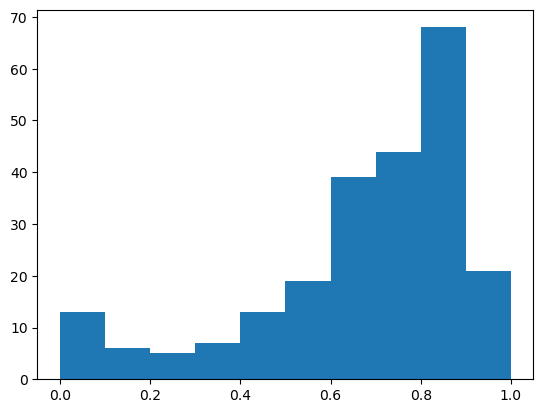

In [9]:
plt.hist(rf_output.r2_test, range = (0,1))

In [57]:
#Drought Sensitivity
results_list = []
for i in range(0,400):
    result = rf_pft(i, inds_test_PFT, xtraits_PFT, 'DroughtSens')
    results_list.append(result)

# Run some post processing
r2_train_list_rf = [r['r2_train'] for r in results_list]
r2_test_list_rf  = [r['r2_test'] for r in results_list]
importances_list_rf = [r['importances'] for r in results_list]

rf_output = rfpp(r2_train_list_rf, r2_test_list_rf, importances_list_rf)
rf_output.to_netcdf(repo_dir+'/supplement/output/ORGFAST_RF_DroughtSens.nc')

0
25
50


/glade/u/home/emargiotta/AridityEnv/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


75


/glade/u/home/emargiotta/AridityEnv/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


100


...

/glade/u/home/emargiotta/AridityEnv/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/glade/u/home/emargiotta/AridityEnv/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


350


/glade/u/home/emargiotta/AridityEnv/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/glade/u/home/emargiotta/AridityEnv/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/glade/u/home/emargiotta/AridityEnv/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/glade/u/home/emargiotta/AridityEnv/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/glade/u/home/emargiotta/AridityEnv/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanv

375


/glade/u/home/emargiotta/AridityEnv/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/glade/u/home/emargiotta/AridityEnv/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/glade/u/home/emargiotta/AridityEnv/lib/python3.11/site-packages/sklearn/metrics/_regression.py:1187: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/glade/u/home/emargiotta/AridityEnv/lib/python3.11/site-packages/sklearn/metrics/_regression.py:1187: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/glade/u/home/emargiotta/AridityEnv/lib/python3.11/site-packages/sklearn/metrics/_regression.py:1187: UndefinedMetricWarni

In [50]:
data = inds_test_PFT.sel(gridcell = 350)
xvar = xtraits_PFT
yvar = 'Stress'
ntrees = 9

scaler_x = StandardScaler()
scaler_y = StandardScaler()

if 'year' in data.dims:
    data = data.median(dim='year', skipna=True)[xvar + [yvar]]
else:
    data = data[xvar + [yvar]]
mean_y = data[yvar].mean(skipna=True).values.item()
std_y = data[yvar].std(skipna=True).values.item()
data[yvar] = data[yvar].where(np.abs(data[yvar] - mean_y) <= 3 * std_y)

data = data.to_dataframe()
data.reset_index(inplace=True)
data = data.replace([np.inf, -np.inf], np.nan).dropna()
ens_column = data['ens']
gridcell_column = data['gridcell'] # Save gridcell column if needed
#data = data.drop(['gridcell', 'ens'], axis=1)

# Fit the scaler only on the X variables (independent variables)
data_x = pd.DataFrame(scaler_x.fit_transform(data[xvar]), columns=xvar) 
if yvar == 'Stress':
    data_y = pd.DataFrame(data[[yvar]], columns=[yvar])
else:
    data_y = pd.DataFrame(
        scaler_y.fit_transform(data[[yvar]]),
        columns=[yvar]
    )

# Concatenate scaled X with original y
data = pd.concat([data_x, data_y, ens_column], axis=1)
#data = data.dropna()

numbers = range(1, 501)
train_numbers, test_numbers = train_test_split(numbers, test_size=0.3, random_state=39)

df_train = data[data.ens.isin(train_numbers)]
df_test = data[data.ens.isin(test_numbers)]

df_train = df_train.dropna()
df_train = df_train.replace([np.inf, -np.inf], np.nan).dropna()
X_train = df_train[xvar]
y_train = df_train[yvar]

df_test = df_test.dropna()
df_test = df_test.replace([np.inf, -np.inf], np.nan).dropna()
X_test = df_test[xvar]
y_test = df_test[yvar]

rf_model = RandomForestRegressor(n_estimators=10, random_state=42, max_depth=ntrees)

# Train the model
rf_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_train = rf_model.predict(X_train)
y_pred_test = rf_model.predict(X_test)

# Compute R² score
r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)

# Revert the predictions and y_test to the original scale if needed
# (since y was not scaled, this step is redundant)

result = permutation_importance(
    rf_model, X_test, y_test, n_repeats=10, random_state=42, n_jobs=2
)
sorted_importances_idx = result.importances_mean.argsort()
importances = pd.DataFrame(
    result.importances[sorted_importances_idx].T,
    columns=X_train.columns[sorted_importances_idx],
)

In [52]:
r2_test

-0.09004178442642408

In [44]:
importances

,wc2wjb0,psi50,kmax,jmaxb1,jmaxb0,slatop,leafcn,medlynslope
0,0.002164,0.002212,0.018912,0.017738,0.042167,0.007401,0.005296,0.076637
1,0.018234,0.014646,0.023459,0.007144,0.028564,0.018567,0.025914,0.046118
2,-0.011951,-0.004964,0.018778,0.019622,0.034063,0.036720,-0.002021,0.094851
3,-0.024802,-0.008291,0.009766,0.056427,0.000069,0.019353,0.052740,0.081906
4,-0.013210,0.012089,0.017202,-0.008427,-0.004658,-0.012659,0.045140,0.050473
5,-0.005437,-0.004847,0.023590,0.037031,-0.018494,0.017100,0.061102,0.068361
6,-0.029780,-0.002085,0.039134,-0.029411,0.005088,0.043433,0.059344,0.057447
7,-0.027125,0.066506,0.032411,0.036372,0.064058,0.037753,0.020369,0.071977
8,0.005755,-0.009662,-0.015642,0.002813,0.000881,0.041557,0.006131,0.050928
9,-0.009058,-0.049719,0.002806,0.031954,0.035977,0.007137,0.016591,0.069499


In [51]:
importances

,wc2wjb0,psi50,kmax,jmaxb1,jmaxb0,slatop,leafcn,medlynslope
0,0.002164,0.002212,0.018912,0.017738,0.042167,0.007401,0.005296,0.076637
1,0.018234,0.014646,0.023459,0.007144,0.028564,0.018567,0.025914,0.046118
2,-0.011951,-0.004964,0.018778,0.019622,0.034063,0.036720,-0.002021,0.094851
3,-0.024802,-0.008291,0.009766,0.056427,0.000069,0.019353,0.052740,0.081906
4,-0.013210,0.012089,0.017202,-0.008427,-0.004658,-0.012659,0.045140,0.050473
5,-0.005437,-0.004847,0.023590,0.037031,-0.018494,0.017100,0.061102,0.068361
6,-0.029780,-0.002085,0.039134,-0.029411,0.005088,0.043433,0.059344,0.057447
7,-0.027125,0.066506,0.032411,0.036372,0.064058,0.037753,0.020369,0.071977
8,0.005755,-0.009662,-0.015642,0.002813,0.000881,0.041557,0.006131,0.050928
9,-0.009058,-0.049719,0.002806,0.031954,0.035977,0.007137,0.016591,0.069499


In [36]:
data_y

,Stress
0,5.555570e-03
1,2.078622e-01
8,2.164713e-01
11,3.772177e-01
12,4.166663e-03
...,...
7485,9.259284e-03
7486,0.000000e+00
7493,9.259284e-03
7496,3.305789e-01
